In [2]:
import os
from pathlib import Path

from dotenv import load_dotenv

load_dotenv()

PROJECT_ROOT = Path(os.getenv("PROJECT_ROOT"))
print(PROJECT_ROOT)
print(PROJECT_ROOT.is_dir())


DATA_DIR = Path(os.getenv("DATA_DIR"))
print(DATA_DIR)
print(DATA_DIR.is_dir())

/home/dyretna/Dokument/Code/GitHub/nightingale_projects/ai_counterfactuals_tests
True
/home/dyretna/Dokument/Code/GitHub/nightingale_projects/ai_counterfactuals_tests/data
True


In [3]:
TRAIN_DATA_PATH = DATA_DIR / "04_multi_target" / "ess_model_ready_v2_train.csv"
print(TRAIN_DATA_PATH.is_file())

TEST_DATA_PATH = DATA_DIR / "04_multi_target" / "ess_model_ready_v2_test.csv"
print(TEST_DATA_PATH.is_file())

True
True


# Loading Data

Hera we are loading the data that does not contain features  
    ["hltprhc", "hltprhb", "hltprdi"]

as they are not conductive for CF calculation

The distibution of train / test == 80 / 20.

We have three target on the same dataset:
- "hltprhb",
- "hltprhc",
- "hltprdi"

In previous steps the distribution of all target classes has been stratifed
into the train / test .csv-files.

We will train 3 RandomforestClassifiers for each target.
They are regarded as Outcome variables, and are not to be used as features when not targets, but are dropped in training.


In [4]:
import pandas as pd

train_df = pd.read_csv(TRAIN_DATA_PATH)
test_df = pd.read_csv(TEST_DATA_PATH)

In [5]:
train_df

,etfruit,eatveg,cgtsmok,alcfreq,slprl,paccnois,bmi,gndr,health,dosprt,hltprhc,hltprhb,hltprdi
0,3.0,3.0,6.0,3.0,2.0,0,36.921078,1,3.0,0.0,0,0,0
1,2.0,3.0,6.0,4.0,1.0,0,22.386314,1,2.0,7.0,0,0,0
2,4.0,4.0,6.0,6.0,1.0,0,30.846277,2,3.0,1.0,0,0,0
3,3.0,2.0,5.0,3.0,2.0,0,23.323418,1,2.0,7.0,0,0,0
4,3.0,2.0,4.0,2.0,2.0,0,30.110279,2,1.0,7.0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32878,2.0,3.0,6.0,5.0,3.0,0,28.373702,2,3.0,0.0,0,1,0
32879,3.0,2.0,5.0,4.0,2.0,0,34.198557,2,2.0,7.0,0,0,0
32880,3.0,3.0,6.0,3.0,2.0,0,23.388687,1,2.0,4.0,0,0,0
32881,3.0,3.0,6.0,7.0,2.0,0,24.049344,1,1.0,3.0,0,0,0


In [6]:
print(train_df.shape)
print(test_df.shape)

(32883, 13)
(8221, 13)


The distribution on the classes for all three targets are as we can see very skewed.
below we can se that the distribution is the same on train and test data-files.

In [7]:
OUTCOMES = ["hltprdi", "hltprhb", "hltprhc"]
FEATURES = [c for c in train_df.columns if c not in OUTCOMES]

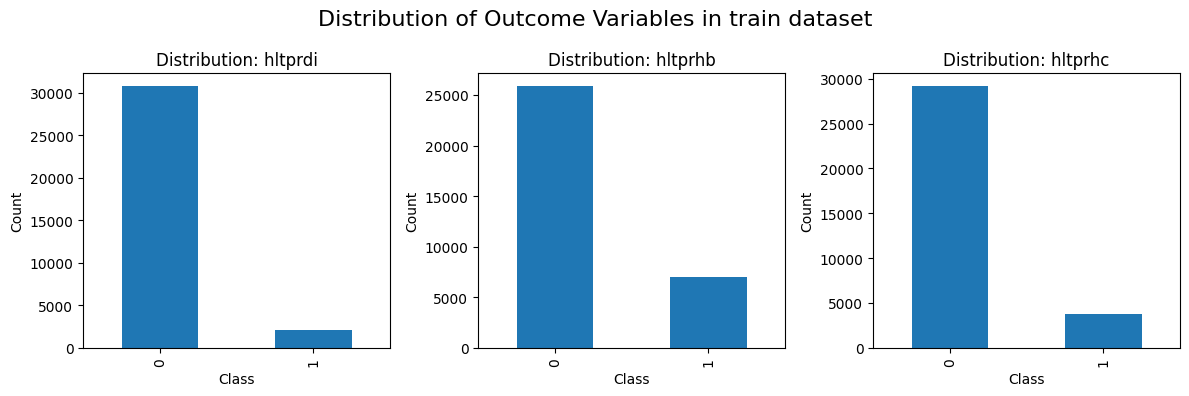

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(OUTCOMES), figsize=(12, 4))

for ax, col in zip(axes, OUTCOMES):
    train_df[col].value_counts().plot(kind="bar", ax=ax)
    ax.set_title(f"Distribution: {col}")
    ax.set_xlabel("Class")
    ax.set_ylabel("Count")

fig.suptitle("Distribution of Outcome Variables in train dataset", fontsize=16)

plt.tight_layout()
plt.subplots_adjust(top=0.85)

plt.tight_layout()
plt.show()

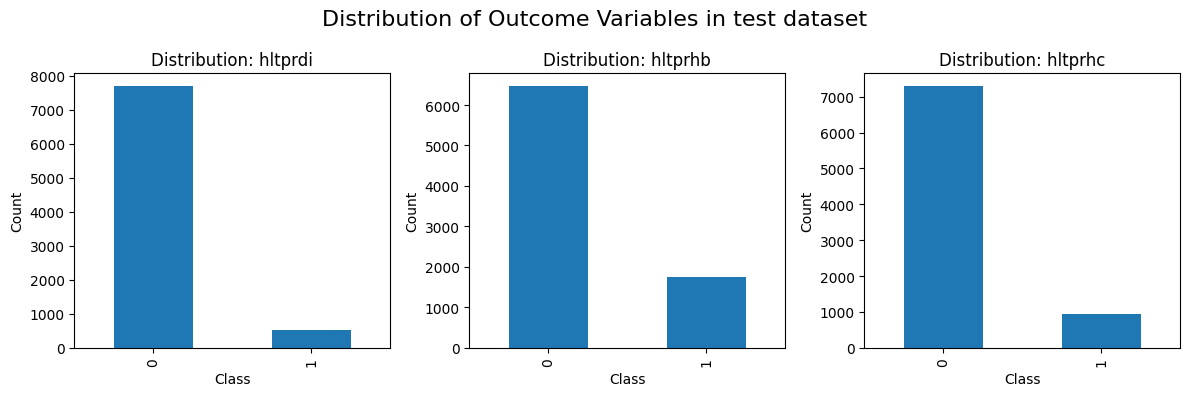

In [9]:
fig, axes = plt.subplots(1, len(OUTCOMES), figsize=(12, 4))

for ax, col in zip(axes, OUTCOMES):
    test_df[col].value_counts().plot(kind="bar", ax=ax)
    ax.set_title(f"Distribution: {col}")
    ax.set_xlabel("Class")
    ax.set_ylabel("Count")

fig.suptitle("Distribution of Outcome Variables in test dataset", fontsize=16)

plt.tight_layout()
plt.subplots_adjust(top=0.85)

plt.tight_layout()
plt.show()

# Setup and training models

In [ ]:
from aiwhatif_cf.multi_target_utils import DataPreprocessor
from aiwhatif_cf.multi_target_utils import ModelTrainer, MultiTargetTrainer

In [11]:
pre_processor = DataPreprocessor(OUTCOMES)
X_train, y_train_dict = pre_processor.split_X_and_targets(train_df)

In [12]:
from sklearn.ensemble import RandomForestClassifier

trainer = ModelTrainer(
    model_cls=RandomForestClassifier,
    model_params={
        "n_estimators": 300,
        "max_depth": None,
        "min_samples_leaf": 5,
        "random_state": 42,
        "n_jobs": -1
    }
)

multi_trainer = MultiTargetTrainer(trainer)
trained_rf_models = multi_trainer.train_all(X_train, y_train_dict)


In [13]:
trained_rf_models["hltprdi"]

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

# predictions

In [14]:
X_test, y_test_dict = pre_processor.split_X_and_targets(test_df)

In [ ]:
from aiwhatif_cf.multi_target_utils import PredictionService

pred_service = PredictionService(trained_rf_models)

pred_service.predict_all(X_test)  # cache predictions
pred_service.summary(X_test, y_test_dict)

{'hltprdi': {'accuracy': 0.9345578396788712, 'roc_auc': 0.7848824493994611},
 'hltprhb': {'accuracy': 0.7900498722783117, 'roc_auc': 0.7592472261925483},
 'hltprhc': {'accuracy': 0.8882131127600049, 'roc_auc': 0.7766942502203038}}

In [16]:
pred_service.accuracy_all(X_test, y_test_dict)

{'hltprdi': 0.9345578396788712,
 'hltprhb': 0.7900498722783117,
 'hltprhc': 0.8882131127600049}

In [17]:
pred_service.roc_auc_all(X_test, y_test_dict)

{'hltprdi': 0.7848824493994611,
 'hltprhb': 0.7592472261925483,
 'hltprhc': 0.7766942502203038}

In [18]:
c_reps = pred_service.classification_reports(X_test, y_test_dict)
c_reps

{'hltprdi': '              precision    recall  f1-score   support\n\n           0       0.93      1.00      0.97      7683\n           1       0.50      0.00      0.00       538\n\n    accuracy                           0.93      8221\n   macro avg       0.72      0.50      0.48      8221\nweighted avg       0.91      0.93      0.90      8221\n',
 'hltprhb': '              precision    recall  f1-score   support\n\n           0       0.81      0.96      0.88      6460\n           1       0.53      0.17      0.26      1761\n\n    accuracy                           0.79      8221\n   macro avg       0.67      0.57      0.57      8221\nweighted avg       0.75      0.79      0.75      8221\n',
 'hltprhc': '              precision    recall  f1-score   support\n\n           0       0.89      0.99      0.94      7288\n           1       0.58      0.06      0.10       933\n\n    accuracy                           0.89      8221\n   macro avg       0.73      0.53      0.52      8221\nweighted

### classification reports

In [19]:
print(c_reps["hltprdi"])

              precision    recall  f1-score   support

           0       0.93      1.00      0.97      7683
           1       0.50      0.00      0.00       538

    accuracy                           0.93      8221
   macro avg       0.72      0.50      0.48      8221
weighted avg       0.91      0.93      0.90      8221



In [20]:
print(c_reps["hltprhb"])

              precision    recall  f1-score   support

           0       0.81      0.96      0.88      6460
           1       0.53      0.17      0.26      1761

    accuracy                           0.79      8221
   macro avg       0.67      0.57      0.57      8221
weighted avg       0.75      0.79      0.75      8221



In [21]:
print(c_reps["hltprhc"])

              precision    recall  f1-score   support

           0       0.89      0.99      0.94      7288
           1       0.58      0.06      0.10       933

    accuracy                           0.89      8221
   macro avg       0.73      0.53      0.52      8221
weighted avg       0.86      0.89      0.85      8221



### confusion plots

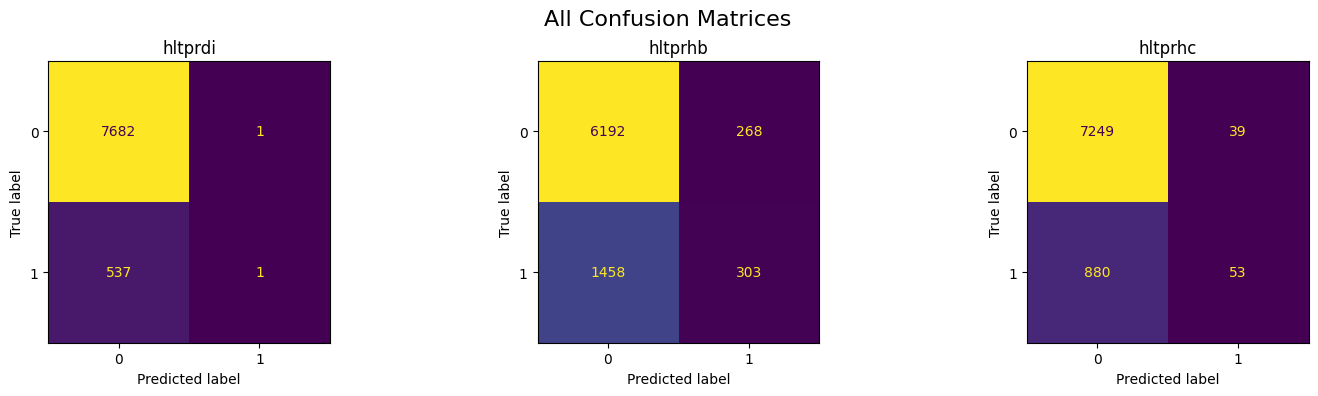

In [22]:
fig = pred_service.plot_confusion_matrix_grid(X_test, y_test_dict)


# testing with gridsearch in 'hltprdi' dataset

In [23]:
TRAIN_DATA_PATH = DATA_DIR / "05_single_target" / "ess_ready_v2_hltprdi_train.csv"
print(TRAIN_DATA_PATH.is_file())

TEST_DATA_PATH = DATA_DIR / "05_single_target" / "ess_ready_v2_hltprdi_test.csv"
print(TEST_DATA_PATH.is_file())

train_df = pd.read_csv(TRAIN_DATA_PATH)
test_df = pd.read_csv(TEST_DATA_PATH)

y = "hltprdi"
X = [c for c in train_df.columns if c not in y]

y_train = train_df[y]
X_train = train_df[X]

y_test = test_df[y]
X_test = test_df[X]

True
True


In [24]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

In [47]:
import os

class RedirectFD:
    def __init__(self, fname):
        self.fname = fname

    def __enter__(self):

        self.f = open(self.fname, "a")
        self.orig_out = os.dup(1)
        self.orig_err = os.dup(2)
        os.dup2(self.f.fileno(), 1)
        os.dup2(self.f.fileno(), 2)
        return self

    def __exit__(self, exc_type, exc_val, exc_tb):
        os.dup2(self.orig_out, 1)
        os.dup2(self.orig_err, 2)
        os.close(self.orig_out)
        os.close(self.orig_err)
        self.f.close()
        return False

In [49]:
from sklearn.model_selection import RandomizedSearchCV


pipeline = Pipeline(
    [
        ("rf", RandomForestClassifier())
    ]
)

param_dist = {
    "rf__n_estimators":     [300, 500, 800],
    "rf__max_depth":        [4,5,8,10,20],
    "rf__min_samples_split":[2,5,10],
    "rf__min_samples_leaf": [1,2,4],
    "rf__max_features":     ["sqrt","log2", None],
    "rf__bootstrap":        [True],
    "rf__class_weight":     ["balanced","balanced_subsample"],
}

rand = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=200,
    scoring="recall_macro",
    n_jobs=-1,
    cv=5,
    verbose=2,
    random_state=42,
)
rand.fit(X_train, y_train)


print("RandomizedSearch Done. best score (cv):", rand.best_score_)
print("Best parameters:")
print(rand.best_params_)


Fitting 5 folds for each of 200 candidates, totalling 1000 fits
[CV] END rf__bootstrap=True, rf__class_weight=balanced, rf__max_depth=10, rf__max_features=sqrt, rf__min_samples_leaf=1, rf__min_samples_split=5, rf__n_estimators=500; total time=   8.4s
[CV] END rf__bootstrap=True, rf__class_weight=balanced, rf__max_depth=10, rf__max_features=sqrt, rf__min_samples_leaf=1, rf__min_samples_split=5, rf__n_estimators=500; total time=   8.3s
[CV] END rf__bootstrap=True, rf__class_weight=balanced, rf__max_depth=10, rf__max_features=sqrt, rf__min_samples_leaf=1, rf__min_samples_split=5, rf__n_estimators=500; total time=   8.6s
[CV] END rf__bootstrap=True, rf__class_weight=balanced, rf__max_depth=10, rf__max_features=sqrt, rf__min_samples_leaf=1, rf__min_samples_split=5, rf__n_estimators=500; total time=   8.6s
[CV] END rf__bootstrap=True, rf__class_weight=balanced, rf__max_depth=10, rf__max_features=sqrt, rf__min_samples_leaf=1, rf__min_samples_split=5, rf__n_estimators=500; total time=   8.7s
[

In [ ]:
import pandas as pd

res = pd.DataFrame(rand.cv_results_)

top_estimators = (
    res
    .sort_values("mean_test_score", ascending=False)
    .head(20)
)

top_estimators = top_estimators.drop(columns=[c for c in top_estimators.columns if c.startswith("param_")])
params = top_estimators["params"].apply(pd.Series)

top_estimators = pd.concat([top_estimators.drop(columns=["params"]), params], axis=1)

top_estimators


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score,rf__n_estimators,rf__min_samples_split,rf__min_samples_leaf,rf__max_features,rf__max_depth,rf__class_weight,rf__bootstrap
69,19.787297,1.021234,0.233542,0.012938,0.729005,0.719538,0.729391,0.734945,0.722126,0.727001,0.005519,1,800,2,4,None,5,balanced,True
116,3.237063,0.174243,0.091197,0.002377,0.736264,0.715400,0.724518,0.726418,0.726720,0.725864,0.006641,2,300,5,1,sqrt,5,balanced,True
43,19.618081,0.718173,0.242562,0.016784,0.728355,0.717706,0.727662,0.733968,0.721047,0.725747,0.005741,3,800,2,1,None,5,balanced,True
145,9.014097,0.228426,0.184310,0.047671,0.735776,0.714993,0.723482,0.729500,0.723402,0.725430,0.006934,4,500,5,2,log2,5,balanced_subsample,True
95,22.600129,0.924607,0.209730,0.017169,0.725369,0.712237,0.727159,0.737973,0.722882,0.725124,0.008251,5,800,10,4,None,4,balanced_subsample,True
170,17.167375,0.941838,0.169393,0.017932,0.726056,0.716464,0.727743,0.733294,0.721475,0.725006,0.005705,6,500,2,4,None,5,balanced_subsample,True
48,24.705951,0.538460,0.250171,0.032305,0.726706,0.717299,0.727884,0.733538,0.719480,0.724982,0.005897,7,800,2,1,None,5,balanced_subsample,True
20,12.100960,0.141000,0.142201,0.004042,0.726300,0.716627,0.726990,0.734050,0.720885,0.724970,0.005909,8,500,5,1,None,5,balanced,True
56,10.040327,0.336138,0.109458,0.005540,0.725384,0.718031,0.725646,0.733968,0.721780,0.724962,0.005290,9,300,2,2,None,5,balanced_subsample,True
169,14.055282,0.319333,0.179868,0.018235,0.725302,0.717787,0.727152,0.732944,0.721454,0.724928,0.005146,10,500,5,2,None,5,balanced,True


In [57]:
best_rf = rand.best_estimator_
best_rf_pred = best_rf.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, best_rf_pred))
print()
print("Roc Score auc score: ", roc_auc_score(y_test, best_rf_pred), "\n")

              precision    recall  f1-score   support

           0       0.97      0.71      0.82      7683
           1       0.15      0.72      0.24       538

    accuracy                           0.71      8221
   macro avg       0.56      0.71      0.53      8221
weighted avg       0.92      0.71      0.78      8221


Roc Score auc score:  0.7144279336361309 



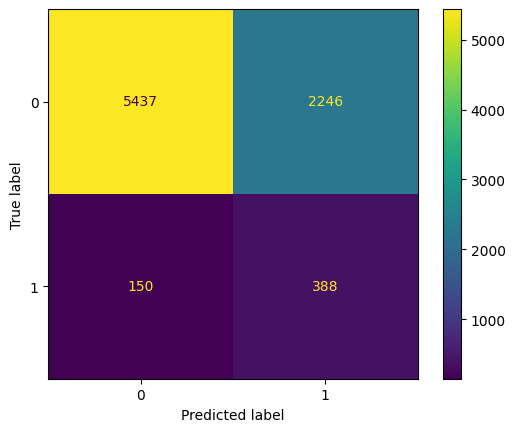

In [61]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, best_rf_pred)

# Analysis

When training machine‑learning classifiers on imbalanced datasets, it is common to observe a systematic shift in error patterns depending on the choice of class weighting. In the unweighted case, models tend to minimize overall error by favoring the majority class, which typically results in high false‑negative rates for the minority class. This occurs because misclassifying minority‑class samples has little impact on the loss function when the majority class dominates the data distribution.

Applying class weights—such as class_weight="balanced" or class_weight="balanced_subsample"—alters the effective loss landscape by increasing the penalty for misclassifying minority‑class samples. The model is therefore encouraged to prioritize sensitivity (recall) for the minority class. A well‑known consequence of this reweighting is a shift in the decision boundary toward the minority class. As a result, the classifier becomes more likely to label ambiguous samples as belonging to the minority class. This reduces false negatives but simultaneously increases false positives.

This phenomenon is not specific to a particular algorithm. It appears across a wide range of models, including Random Forests, Complement Naive Bayes, and other probabilistic or ensemble methods. The underlying mechanism is the same: class weighting modifies the optimization objective so that the model trades precision for recall in the minority class. When the dataset is strongly imbalanced, this tradeoff becomes especially pronounced, and the model may converge to a region of the parameter space where improvements in recall necessarily come at the cost of increased false‑positive rates.

In the experiments above, Random Forest performance plateaued across a broad hyperparameter search, with mean macro‑recall values varying only marginally. This indicates that the model has reached its performance ceiling under the current data distribution and feature representation. Further hyperparameter tuning is unlikely to yield substantial improvements. Instead, adjustments to the decision threshold, probability calibration, or the use of alternative model families (e.g., gradient‑boosted trees) may be required to achieve a more favorable balance between false positives and false negatives.